In [5]:
### PART 1

In [6]:
## Task A — Network Construction

#This section describes how the Wikidata editor network was constructed from the dataset.

In [7]:
# needed libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [8]:
# Load dataset
df = pd.read_csv("REQUESTS_FOR_COMMENT.csv")

print(df.head())
print(df.columns)
print("Rows:", len(df))

                                      thread_subject        username  \
0  19830101dateofbirthvs19880000dateofbirthbothon...          Tidoni   
1  19830101dateofbirthvs19880000dateofbirthbothon...  Matěj Suchánek   
2  Abusefilterviewprivateandabusefilterlogprivate...   John F. Lewis   
3  Abusefilterviewprivateandabusefilterlogprivate...     FrigidNinja   
4  Abusefilterviewprivateandabusefilterlogprivate...       Hazard-SJ   

                                           page_name  
0  WikidataRequestsforcomment19830101dateofbirthv...  
1  WikidataRequestsforcomment19830101dateofbirthv...  
2  WikidataRequestsforcommentAbusefilterviewpriva...  
3  WikidataRequestsforcommentAbusefilterviewpriva...  
4  WikidataRequestsforcommentAbusefilterviewpriva...  
Index(['thread_subject', 'username', 'page_name'], dtype='object')
Rows: 2925


In [9]:
import networkx as nx
from itertools import combinations

# Create an empty graph
G = nx.Graph()

# Group data by page and thread (users in same discussion)
groups = df.groupby(['page_name', 'thread_subject'])

# Loop through each discussion group
for (page, thread), group in groups:
    # Get unique users in this discussion
    users = group['username'].unique()
    
    # Create connections between all pairs of users
    for u1, u2 in combinations(users, 2):
        # If edge already exists, increase weight
        if G.has_edge(u1, u2):
            G[u1][u2]['weight'] += 1
        # Otherwise create a new edge
        else:
            G.add_edge(u1, u2, weight=1)

# Print network statistics
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 837
Edges: 27569


In [10]:
# Calculate density
density = nx.density(G)
print("Density:", density)

Density: 0.07879874008906267


In [11]:
# Calculate isolated nodes
isolated = list(nx.isolates(G))
print("Isolated nodes:", len(isolated))

Isolated nodes: 0


In [12]:
df_items = pd.read_csv("ITEMS.csv")

print(df_items.head())
print(df_items.columns)
print("Rows:", len(df_items))

         thread_subject     username            page_name
0   TimeZone (I guess)           YMS      TalkQ10000.json
1            No subject  Estopedist1   TalkQ10009180.json
2              Leitung            UV    TalkQ1001338.json
3            No subject  Estopedist1  TalkQ100137687.json
4            No subject        Trade  TalkQ100148221.json
Index(['thread_subject', 'username', 'page_name'], dtype='object')
Rows: 25601


In [13]:
import networkx as nx
from itertools import combinations

G_items = nx.Graph()

groups = df_items.groupby(['page_name', 'thread_subject'])

for (page, thread), group in groups:
    users = group['username'].unique()
    
    for u1, u2 in combinations(users, 2):
        if G_items.has_edge(u1, u2):
            G_items[u1][u2]['weight'] += 1
        else:
            G_items.add_edge(u1, u2, weight=1)

print("Nodes:", G_items.number_of_nodes())
print("Edges:", G_items.number_of_edges())

Nodes: 3539
Edges: 7252


In [14]:
density = nx.density(G_items)
isolated = len(list(nx.isolates(G_items)))

print("Density:", density)
print("Isolated nodes:", isolated)

Density: 0.0011583755970578026
Isolated nodes: 0


In [15]:
df_users = pd.read_csv("USERS.csv")

print(df_users.head())
print(df_users.columns)
print("Rows:", len(df_users))

  thread_subject        username                          page_name
0     No subject  Liuxinyu970226  Usertalk000accountdeleted000.json
1     No subject      M2k~dewiki          Usertalk000selina000.json
2     No subject        Peaceray                Usertalk001Jrm.json
3     No subject  Liuxinyu970226             Usertalk007hemant.json
4     No subject          ToJack           Usertalk011ZezoTito.json
Index(['thread_subject', 'username', 'page_name'], dtype='object')
Rows: 171692


In [16]:
import networkx as nx
from itertools import combinations

G_users = nx.Graph()

groups = df_users.groupby(['page_name', 'thread_subject'])

for (page, thread), group in groups:
    users = group['username'].unique()
    
    for u1, u2 in combinations(users, 2):
        if G_users.has_edge(u1, u2):
            G_users[u1][u2]['weight'] += 1
        else:
            G_users.add_edge(u1, u2, weight=1)

print("Nodes:", G_users.number_of_nodes())
print("Edges:", G_users.number_of_edges())

Nodes: 8390
Edges: 24692


In [17]:
density = nx.density(G_users)
isolated = len(list(nx.isolates(G_users)))

print("Density:", density)
print("Isolated nodes:", isolated)

Density: 0.0007016396265556334
Isolated nodes: 0


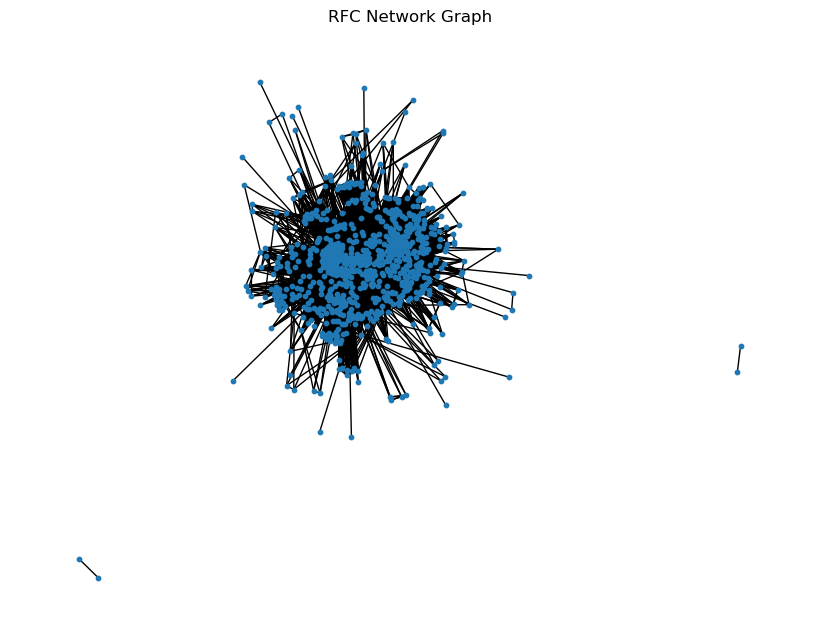

In [18]:
import matplotlib.pyplot as plt

# Visualisation
plt.figure(figsize=(8,6))
nx.draw(G, node_size=10)
plt.title("RFC Network Graph")
plt.show()

In [19]:
## Task B — Network Metrics

#In this section, we analyse the structural properties of the network and compare it to a random network.

In [20]:
import networkx as nx

# Number of nodes (users)
num_nodes = G.number_of_nodes()

# Number of edges (connections between users)
num_edges = G.number_of_edges()

# Network density (how connected the network is)
density = nx.density(G)

# Average degree (average number of connections per user)
avg_degree = sum(dict(G.degree()).values()) / num_nodes

# Average clustering coefficient (tendency to form groups)
clustering = nx.average_clustering(G)

# Check if graph is connected
is_connected = nx.is_connected(G)

# Average shortest path length (only if connected)
if is_connected:
    avg_path_length = nx.average_shortest_path_length(G)
else:
    avg_path_length = "Graph not fully connected"

print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", density)
print("Average Degree:", avg_degree)
print("Clustering Coefficient:", clustering)
print("Connected:", is_connected)
print("Average Path Length:", avg_path_length)

Nodes: 837
Edges: 27569
Density: 0.07879874008906267
Average Degree: 65.8757467144564
Clustering Coefficient: 0.8294447896850659
Connected: False
Average Path Length: Graph not fully connected


In [21]:
# Extract largest connected component
largest_cc = max(nx.connected_components(G), key=len)

# Create subgraph
G_cc = G.subgraph(largest_cc).copy()

# Path length on connected component
avg_path_length = nx.average_shortest_path_length(G_cc)

print("Nodes in largest component:", G_cc.number_of_nodes())
print("Average Path Length (connected part):", avg_path_length)

Nodes in largest component: 833
Average Path Length (connected part): 2.0867375796472434


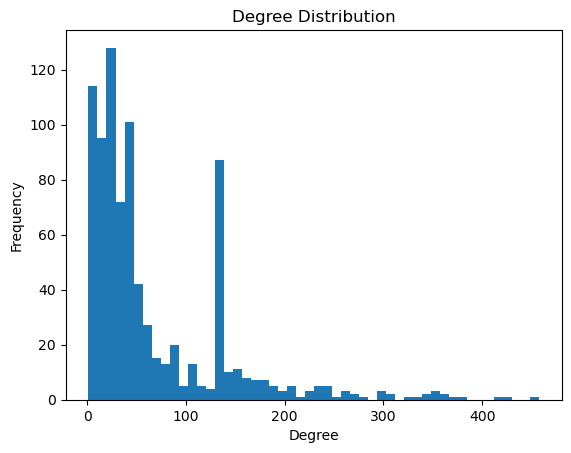

In [22]:
import matplotlib.pyplot as plt

degrees = [d for n, d in G.degree()]

plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

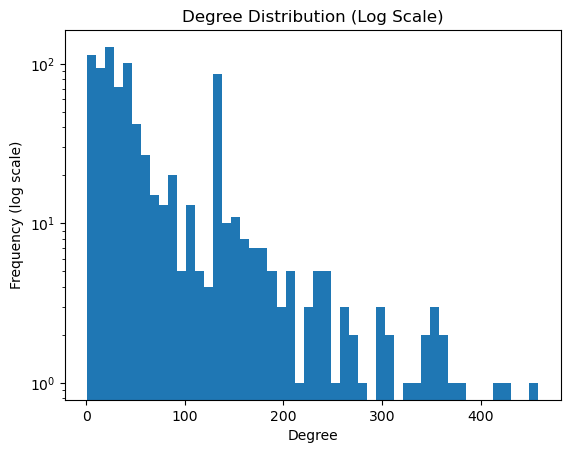

In [23]:
plt.hist(degrees, bins=50, log=True)
plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Frequency (log scale)")
plt.show()

In [24]:
real_clustering = nx.average_clustering(G)

print("Real Clustering:", real_clustering)
print("Average Path Length (from component):", avg_path_length)

Real Clustering: 0.8294447896850659
Average Path Length (from component): 2.0867375796472434


In [25]:
# Create random graph
random_graph = nx.gnm_random_graph(num_nodes, num_edges)

# Clustering
random_clustering = nx.average_clustering(random_graph)

# Path length
if nx.is_connected(random_graph):
    random_path_length = nx.average_shortest_path_length(random_graph)
else:
    largest_cc_rand = max(nx.connected_components(random_graph), key=len)
    G_rand_cc = random_graph.subgraph(largest_cc_rand).copy()
    random_path_length = nx.average_shortest_path_length(G_rand_cc)

print("Random Clustering:", random_clustering)
print("Random Path Length:", random_path_length)

Random Clustering: 0.07841436867868075
Random Path Length: 1.9263775273962032


In [26]:
## Task C — Epidemic Models

# In this task, the spread of controversial behaviour among Wikipedia editors is modelled using concepts inspired by epidemic processes.

In [27]:
import random

nodes = list(G.nodes())
n1, n2 = random.sample(nodes, 2)

print("Editor 1:", n1)
print("Editor 2:", n2)

Editor 1: TED
Editor 2: Base


In [28]:
import networkx as nx

try:
    dist = nx.shortest_path_length(G, n1, n2)
    print("Shortest path:", dist)
except:
    print("No path between editors")

Shortest path: 2


In [29]:
neighbors_1 = list(G.neighbors(n1))
neighbors_2 = list(G.neighbors(n2))

print("Neighbors of Editor 1:", len(neighbors_1))
print("Neighbors of Editor 2:", len(neighbors_2))

Neighbors of Editor 1: 136
Neighbors of Editor 2: 27


In [30]:
priority_nodes = set(neighbors_1 + neighbors_2)
print("Priority nodes to check:", len(priority_nodes))

Priority nodes to check: 159


In [31]:
print("Editor 1:", n1)
print("Editor 2:", n2)

try:
    dist = nx.shortest_path_length(G, n1, n2)
    print("Shortest path:", dist)
except:
    print("No path between editors")

neighbors_1 = list(G.neighbors(n1))
neighbors_2 = list(G.neighbors(n2))

print("Neighbours of Editor 1:", len(neighbors_1))
print("Neighbours of Editor 2:", len(neighbors_2))

priority_nodes = set(neighbors_1 + neighbors_2)
print("Priority nodes to check:", len(priority_nodes))

Editor 1: TED
Editor 2: Base
Shortest path: 2
Neighbours of Editor 1: 136
Neighbours of Editor 2: 27
Priority nodes to check: 159


In [32]:
### PART 2

In [33]:
## Task A - Spatial Networks and Planarity

In [34]:
import pandas as pd

files = ["2012.csv", "2011.csv", "2010.csv"]

dfs = [pd.read_csv(f, encoding="latin1") for f in files]

df = pd.concat(dfs, ignore_index=True)

df.columns = df.columns.str.strip()

print("Total accidents:", len(df))

Total accidents: 8199


In [35]:
center_easting = 430000
center_northing = 434000

In [36]:
area = df[
    (df["Easting"] > center_easting - 550) &
    (df["Easting"] < center_easting + 550) &
    (df["Northing"] > center_northing - 550) &
    (df["Northing"] < center_northing + 550)
]

print("Accidents in area:", len(area))

Accidents in area: 318


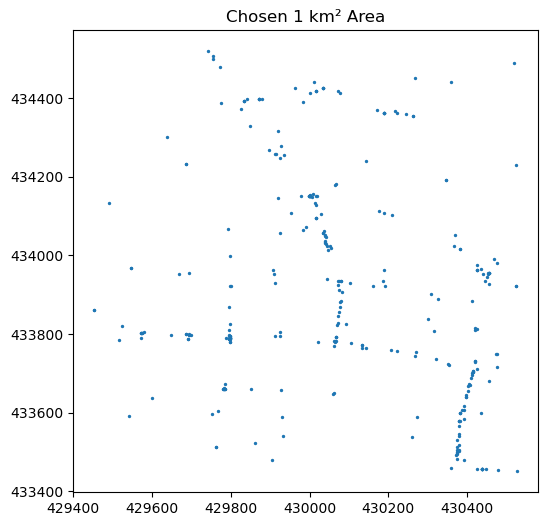

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(area["Easting"], area["Northing"], s=2)
plt.title("Chosen 1 km² Area")
plt.show()

In [38]:
from pyproj import Transformer

transformer = Transformer.from_crs("epsg:27700", "epsg:4326")

lat, lon = transformer.transform(center_easting, center_northing)

print("Latitude:", lat)
print("Longitude:", lon)

Latitude: 53.801441535013616
Longitude: -1.5459891638590544


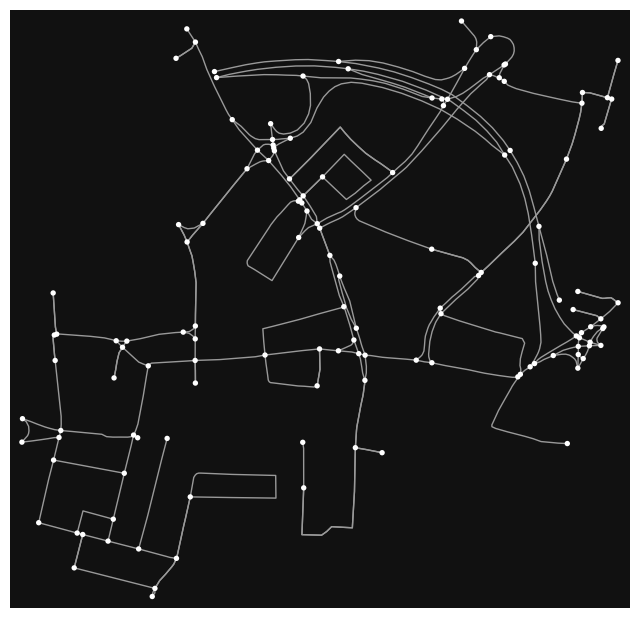

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [39]:
import osmnx as ox

G = ox.graph_from_point((lat, lon), dist=500, network_type='drive')

ox.plot_graph(G)

In [40]:
import osmnx as ox

# Project graph 
G_proj = ox.project_graph(G)

# Get GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G_proj)

# Area 
area_km2 = 1.21 

# --- Metrics ---

# Avg street length
avg_street_length = edges["length"].mean()

# Node density
node_density = len(nodes) / area_km2

# Intersection density (nodes with degree >= 3)
import networkx as nx
G_undirected = G_proj.to_undirected()

intersection_nodes = [n for n, d in G_undirected.degree() if d >= 3]
intersection_density = len(intersection_nodes) / area_km2

# Edge density (total road length per km²)
total_road_length = edges["length"].sum()  # meters
edge_density = total_road_length / area_km2  # meters per km²

# Print results
print("Avg street length:", avg_street_length)
print("Node density:", node_density)
print("Intersection density:", intersection_density)
print("Edge density:", edge_density)

Avg street length: 73.3778898977034
Node density: 114.04958677685951
Intersection density: 80.99173553719008
Edge density: 13584.006063707075


In [41]:
stats = ox.basic_stats(G_proj)
print("Circuitry:", stats['circuity_avg'])

Circuitry: 1.1228383487264257


In [42]:
import networkx as nx

G_undirected = G_proj.to_undirected()

largest_cc = max(nx.connected_components(G_undirected), key=len)
G_sub = G_undirected.subgraph(largest_cc)

diameter = nx.diameter(G_sub)
print("Diameter:", diameter)

Diameter: 26


In [43]:
is_planar, _ = nx.check_planarity(G_undirected)
print("Is planar:", is_planar)

Is planar: False


In [44]:
## Task B — Road Accidents

In [45]:
area = df[
    (df["Easting"] > center_easting - 550) &
    (df["Easting"] < center_easting + 550) &
    (df["Northing"] > center_northing - 550) &
    (df["Northing"] < center_northing + 550)
]

print("Accidents in area:", len(area))

Accidents in area: 318


In [66]:
from pyproj import Transformer

transformer = Transformer.from_crs("epsg:27700", "epsg:4326")

lats, lons = transformer.transform(
    area["Easting"].values,
    area["Northing"].values
)

coords = np.column_stack((lons, lats))

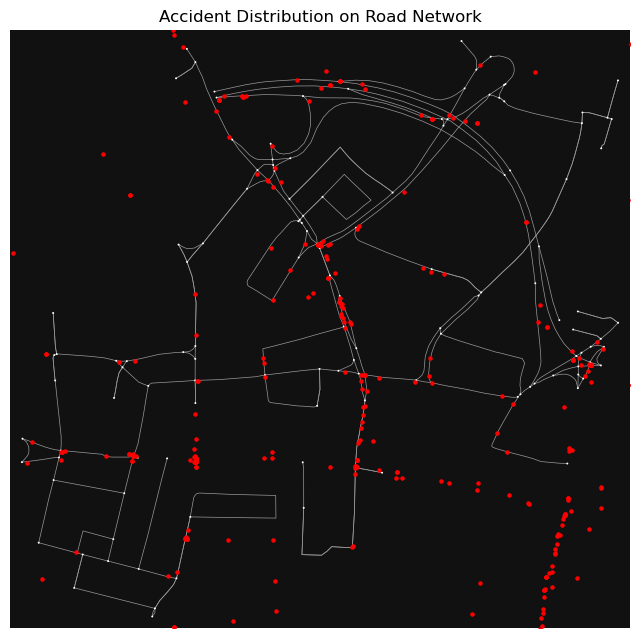

In [67]:
fig, ax = ox.plot_graph(G, node_size=2, edge_linewidth=0.5, show=False)
ax.scatter(lons, lats, c='red', s=5)

plt.title("Accident Distribution on Road Network")
plt.show()

In [54]:
!pip install libpysal esda

In [68]:
from scipy.spatial import cKDTree

tree = cKDTree(coords)

# count neighbours within radius
counts = tree.query_ball_point(coords, r=0.001)

values = np.array([len(c) for c in counts])

In [69]:
from libpysal.weights import KNN
from esda.moran import Moran

w = KNN.from_array(coords, k=5)
w.transform = 'r'

moran = Moran(values, w)

print("Moran’s I:", moran.I)
print("p-value:", moran.p_sim)

Moran’s I: 0.83850679697873
p-value: 0.001


C:\Users\Petela\anaconda3\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [55]:
import networkx as nx
import osmnx as ox
from scipy.spatial import cKDTree
import numpy as np

# Convert graph
G_undirected = G.to_undirected()

# Get intersections (degree >= 3)
intersections = [n for n, d in G_undirected.degree() if d >= 3]

# Get node coordinates
nodes, edges = ox.graph_to_gdfs(G)

intersection_points = nodes.loc[intersections]

# Build KDTree
tree = cKDTree(intersection_points[['x', 'y']].values)

# Accident points
accident_points = np.column_stack((lons, lats))

# Distances
distances, _ = tree.query(accident_points)

print("Average distance to intersection:", distances.mean())

Average distance to intersection: 0.0009743324959170662


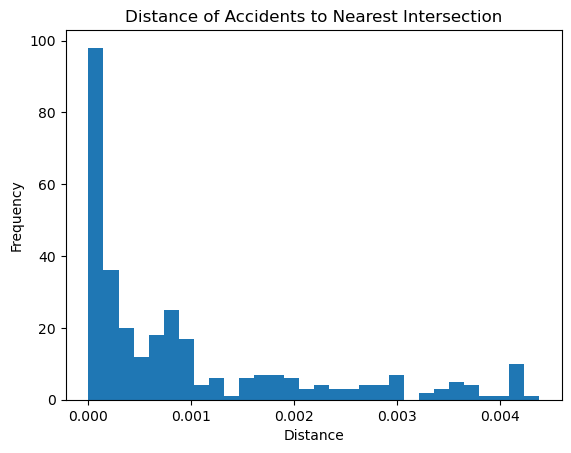

In [56]:
import matplotlib.pyplot as plt

plt.hist(distances, bins=30)
plt.title("Distance of Accidents to Nearest Intersection")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

In [ ]:
## Task C — Voronoi Diagrams

In [57]:
import numpy as np

# (lat, lon) — Leeds
seeds = np.array([
    [53.8008, -1.5491],  # centre
    [53.8100, -1.5200],  # east
    [53.7800, -1.5800],  # west
    [53.7700, -1.5400]   # south
])

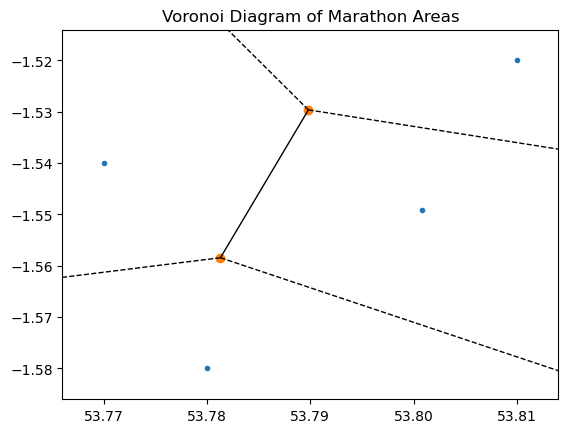

In [58]:
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt

vor = Voronoi(seeds)

fig = voronoi_plot_2d(vor)
plt.scatter(seeds[:,1], seeds[:,0], c='red')  # lon, lat for plotting
plt.title("Voronoi Diagram of Marathon Areas")
plt.show()

In [59]:
nodes, edges = ox.graph_to_gdfs(G)

from scipy.spatial import cKDTree

tree = cKDTree(seeds)

node_coords = np.column_stack((nodes['y'], nodes['x']))

_, labels = tree.query(node_coords)

nodes['cell'] = labels

In [60]:
import networkx as nx
import random

def find_loop(G, start_node, target_length=42000):
    nodes = list(G.nodes)
    
    # random far node
    far_node = random.choice(nodes)
    
    try:
        path1 = nx.shortest_path(G, start_node, far_node, weight='length')
        path2 = nx.shortest_path(G, far_node, start_node, weight='length')
        
        full_path = path1 + path2
        
        # length
        total_length = 0
        for i in range(len(full_path)-1):
            edge_data = G.get_edge_data(full_path[i], full_path[i+1])[0]
            total_length += edge_data.get('length', 0)
        
        return full_path, total_length
    
    except:
        return None, 0

In [61]:
for i in range(4):
    cell_nodes = nodes[nodes['cell'] == i].index

    if len(cell_nodes) == 0:
        print(f"Cell {i}: no nodes")
        continue

    start = random.choice(list(cell_nodes))
    path, length = find_loop(G, start)

    if path:
        print(f"Cell {i}: loop found, length = {length}")
    else:
        print(f"Cell {i}: no loop found")

Cell 0: no loop found
Cell 1: no nodes
Cell 2: no nodes
Cell 3: no nodes


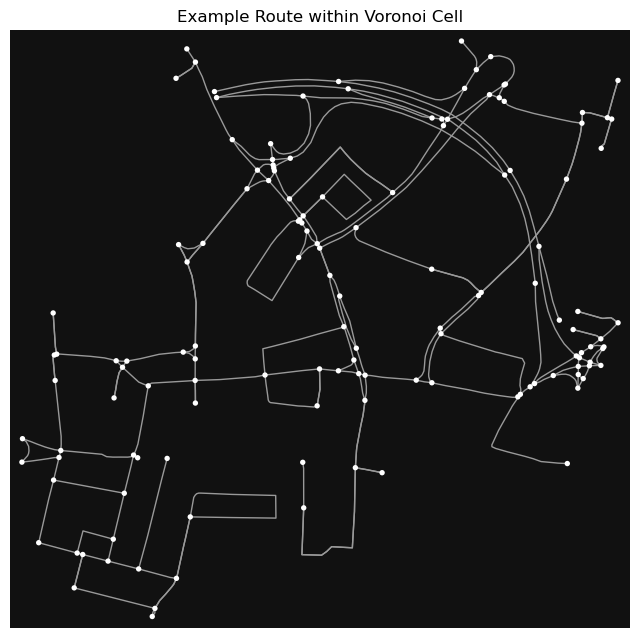

In [62]:
fig, ax = ox.plot_graph(G, show=False)

if path:
    xs = [nodes.loc[n]['x'] for n in path]
    ys = [nodes.loc[n]['y'] for n in path]

    ax.plot(xs, ys, c='red', linewidth=2)

plt.title("Example Route within Voronoi Cell")
plt.show()

In [63]:
results = []

for i in range(4):
    cell_nodes = nodes[nodes['cell'] == i].index

    if len(cell_nodes) == 0:
        results.append(False)
        continue

    start = random.choice(list(cell_nodes))
    path, length = find_loop(G, start)

    results.append(path is not None)

print(results)

[False, False, False, False]
